# Experiment 7 — Bagging, Boosting, and Stacked Ensemble Models

**Course:** ICS1512 – Machine Learning Laboratory
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) — 569 samples, 30 numerical features, binary target (Malignant / Benign)

This notebook implements and compares three ensemble learning strategies:
- **Bagging** (Bootstrap Aggregation) with a Decision Tree base estimator
- **Boosting** (AdaBoost and Gradient Boosting)
- **Stacked Ensemble** (SVM + Naive Bayes + Decision Tree base learners, Logistic Regression meta-learner)

All hyperparameters are selected using 5-fold cross-validation, and models are compared on accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                              RocCurveDisplay, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load and Preprocess the Dataset

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0 = malignant, 1 = benign
target_names = data.target_names

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Feature dtypes:\n")
print(df.dtypes.value_counts())
print("\nClass mapping:", dict(enumerate(target_names)))
print("\nMissing values per column:\n", df.isnull().sum().sum(), "total missing values")

Feature dtypes:

float64    30
int64       1
Name: count, dtype: int64

Class mapping: {0: np.str_('malignant'), 1: np.str_('benign')}

Missing values per column:
 0 total missing values


## 2. Exploratory Data Analysis

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


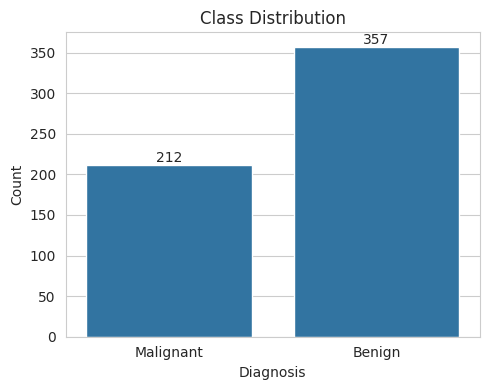

In [5]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x=df["target"].map({0:"Malignant", 1:"Benign"}))
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()

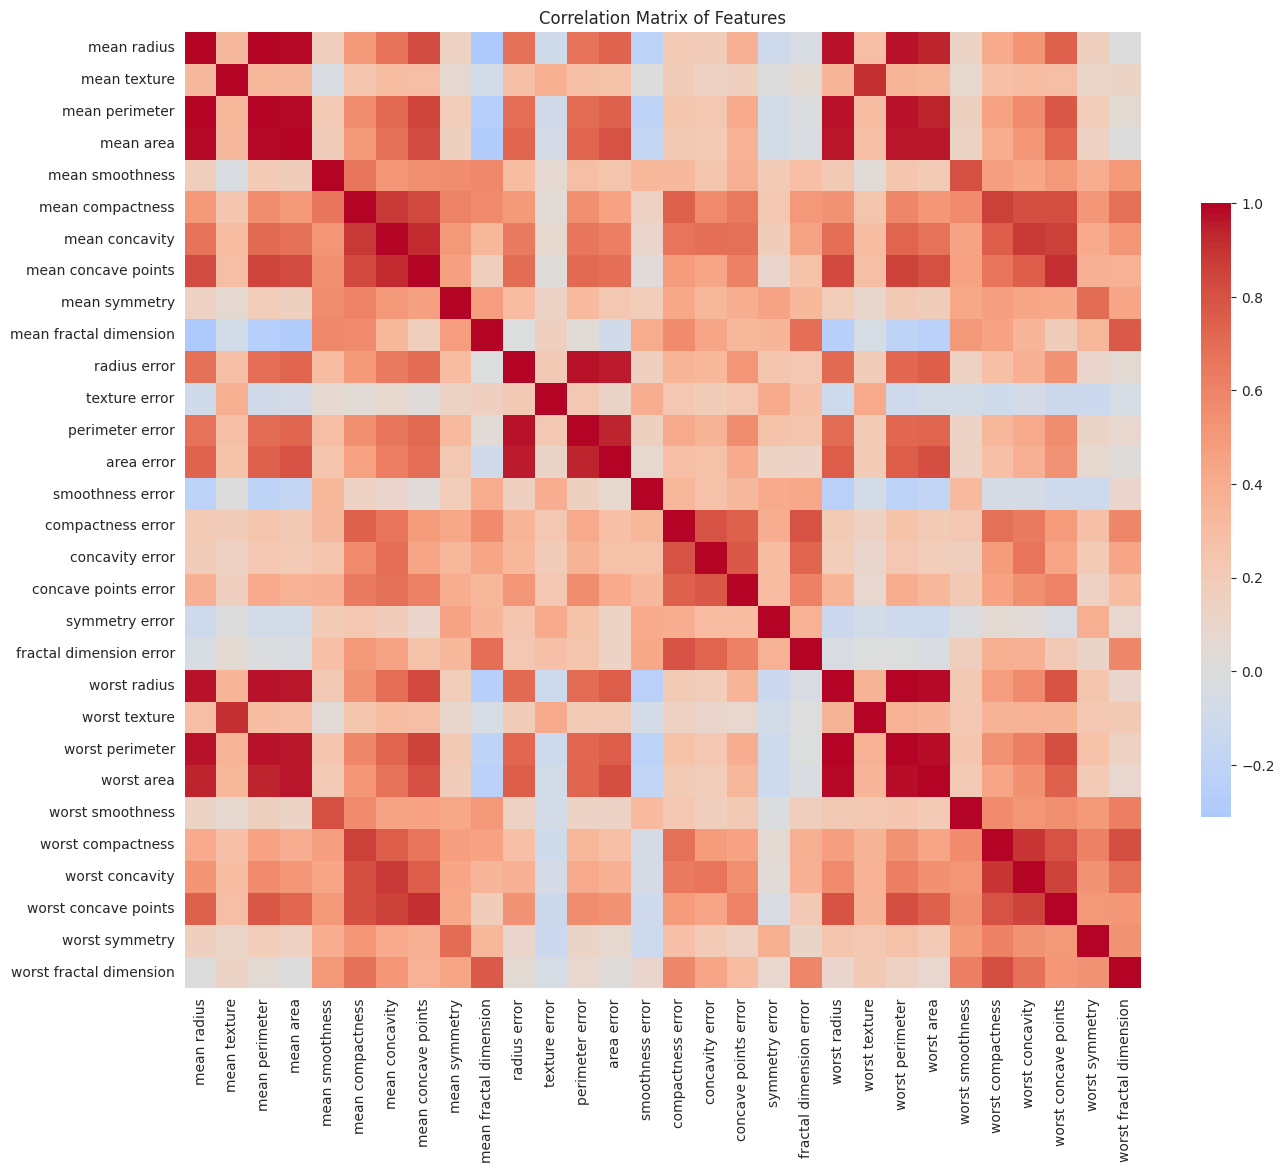

In [6]:
plt.figure(figsize=(14,12))
corr = df.drop(columns=["target"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink":0.6})
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()

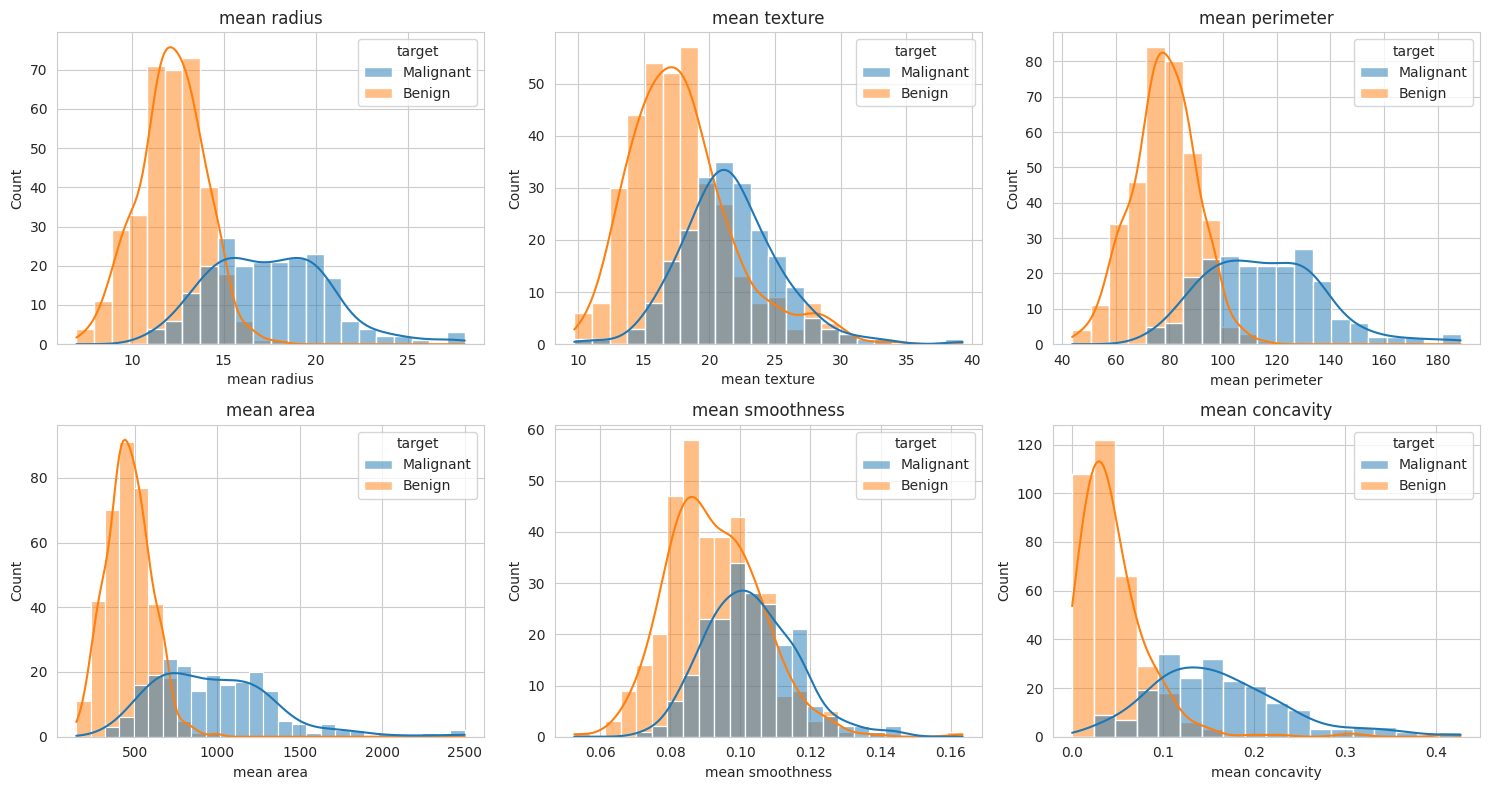

In [7]:
cols_to_plot = ["mean radius", "mean texture", "mean perimeter", "mean area",
                "mean smoothness", "mean concavity"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), cols_to_plot):
    sns.histplot(data=df, x=col, hue=df["target"].map({0:"Malignant",1:"Benign"}), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Inference:** The dataset is moderately imbalanced (more benign than malignant cases), has no missing
values, and several features are strongly correlated with one another (e.g. mean radius, mean perimeter,
and mean area), which is expected since they are geometric derivatives of one another. Feature
distributions show visible separation between the two classes for several mean-value features,
suggesting they will be useful for classification.

## 3. Train-Test Split and Feature Scaling

In [8]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (455, 30)  Test shape: (114, 30)


## 4. Bagging Classifier

Base estimator: Decision Tree. Hyperparameters tuned via 5-fold CV: `n_estimators`, `max_samples`, `max_features`.

In [9]:
bagging_param_grid = {
    "n_estimators": [10, 25, 50, 100],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0],
}

bagging_base = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    random_state=RANDOM_STATE
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

bagging_grid = GridSearchCV(
    bagging_base, bagging_param_grid, cv=cv5,
    scoring={"accuracy": "accuracy", "f1": "f1"}, refit="accuracy", n_jobs=-1
)
bagging_grid.fit(X_train_scaled, y_train)

bagging_results = pd.DataFrame(bagging_grid.cv_results_)[
    ["param_n_estimators", "param_max_samples", "param_max_features",
     "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_n_estimators": "n_estimators",
    "param_max_samples": "max_samples",
    "param_max_features": "max_features",
    "mean_test_accuracy": "Avg CV Accuracy",
    "mean_test_f1": "Avg CV F1 Score",
})
bagging_results["Avg CV Accuracy (%)"] = (bagging_results["Avg CV Accuracy"] * 100).round(2)
bagging_results = bagging_results[["n_estimators", "max_samples", "max_features",
                                    "Avg CV Accuracy (%)", "Avg CV F1 Score"]]
bagging_results.sort_values("Avg CV Accuracy (%)", ascending=False).head(10)

,n_estimators,max_samples,max_features,Avg CV Accuracy (%),Avg CV F1 Score
9,25,1.0,0.5,96.48,0.971985
1,25,0.5,0.5,96.26,0.970279
7,100,0.7,0.5,96.04,0.968288
2,50,0.5,0.5,96.04,0.968138
13,25,0.5,0.7,96.04,0.968190
11,100,1.0,0.5,96.04,0.968418
10,50,1.0,0.5,96.04,0.968325
6,50,0.7,0.5,95.82,0.966520
19,100,0.7,0.7,95.82,0.966578
31,100,0.7,1.0,95.82,0.966457


In [10]:
print("Best Bagging params:", bagging_grid.best_params_)
print("Best Bagging CV accuracy: {:.4f}".format(bagging_grid.best_score_))
best_bagging = bagging_grid.best_estimator_

Best Bagging params: {'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 25}
Best Bagging CV accuracy: 0.9648


## 5. Boosting Classifiers

Two boosting algorithms are tuned: **AdaBoost** and **Gradient Boosting**.
Hyperparameters tuned: `n_estimators`, `learning_rate`, and (for Gradient Boosting) `max_depth`.

In [11]:
ada_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.5, 1.0],
}

ada_base = AdaBoostClassifier(random_state=RANDOM_STATE)
ada_grid = GridSearchCV(ada_base, ada_param_grid, cv=cv5,
                         scoring={"accuracy": "accuracy", "f1": "f1"}, refit="accuracy", n_jobs=-1)
ada_grid.fit(X_train_scaled, y_train)

ada_results = pd.DataFrame(ada_grid.cv_results_)[
    ["param_n_estimators", "param_learning_rate", "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_n_estimators": "n_estimators",
    "param_learning_rate": "learning_rate",
    "mean_test_accuracy": "Avg CV Accuracy",
    "mean_test_f1": "Avg CV F1 Score",
})
ada_results["Avg CV Accuracy (%)"] = (ada_results["Avg CV Accuracy"] * 100).round(2)
ada_results = ada_results[["n_estimators", "learning_rate", "Avg CV Accuracy (%)", "Avg CV F1 Score"]]
print("=== AdaBoost ===")
print("Best params:", ada_grid.best_params_, " Best CV accuracy: {:.4f}".format(ada_grid.best_score_))
ada_results.sort_values("Avg CV Accuracy (%)", ascending=False).head(10)

=== AdaBoost ===
Best params: {'learning_rate': 1.0, 'n_estimators': 100}  Best CV accuracy: 0.9802


,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
10,100,1.00,98.02,0.984378
11,150,1.00,97.80,0.982698
8,150,0.50,97.36,0.979160
7,100,0.50,97.36,0.979189
6,50,0.50,96.70,0.973667
9,50,1.00,96.70,0.974002
5,150,0.10,96.48,0.972050
4,100,0.10,96.04,0.968602
3,50,0.10,95.38,0.963289
1,100,0.01,93.41,0.947975


In [12]:
gb_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4],
}

gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_grid = GridSearchCV(gb_base, gb_param_grid, cv=cv5,
                        scoring={"accuracy": "accuracy", "f1": "f1"}, refit="accuracy", n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)

gb_results = pd.DataFrame(gb_grid.cv_results_)[
    ["param_n_estimators", "param_learning_rate", "param_max_depth", "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_n_estimators": "n_estimators",
    "param_learning_rate": "learning_rate",
    "param_max_depth": "max_depth",
    "mean_test_accuracy": "Avg CV Accuracy",
    "mean_test_f1": "Avg CV F1 Score",
})
gb_results["Avg CV Accuracy (%)"] = (gb_results["Avg CV Accuracy"] * 100).round(2)
gb_results = gb_results[["n_estimators", "learning_rate", "max_depth", "Avg CV Accuracy (%)", "Avg CV F1 Score"]]
print("=== Gradient Boosting ===")
print("Best params:", gb_grid.best_params_, " Best CV accuracy: {:.4f}".format(gb_grid.best_score_))
gb_results.sort_values("Avg CV Accuracy (%)", ascending=False).head(10)

=== Gradient Boosting ===
Best params: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 150}  Best CV accuracy: 0.9736


,n_estimators,learning_rate,max_depth,Avg CV Accuracy (%),Avg CV F1 Score
20,150,0.2,2,97.36,0.978945
19,100,0.2,2,96.92,0.975496
23,150,0.2,3,96.70,0.973820
11,150,0.1,2,96.48,0.971894
22,100,0.2,3,96.48,0.971927
18,50,0.2,2,96.26,0.970126
10,100,0.1,2,96.26,0.970219
16,100,0.1,4,96.04,0.968470
14,150,0.1,3,95.82,0.966860
24,50,0.2,4,95.82,0.966514


In [13]:
# Pick the better of the two boosting algorithms as "Boosting" for the final comparison
if ada_grid.best_score_ >= gb_grid.best_score_:
    best_boosting = ada_grid.best_estimator_
    best_boosting_name = "AdaBoost"
else:
    best_boosting = gb_grid.best_estimator_
    best_boosting_name = "Gradient Boosting"
print("Selected boosting model:", best_boosting_name)

Selected boosting model: AdaBoost


## 6. Stacked Ensemble

Base models: **SVM**, **Naive Bayes**, **Decision Tree**. Meta-learner: **Logistic Regression**.
A small grid over the base-model configuration and the SVM kernel / regularisation is explored via 5-fold CV.

In [14]:
stack_param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"],
    "dt__max_depth": [3, 5, None],
    "final_estimator__C": [0.1, 1, 10],
}

def make_stack(svm_kernel="rbf", svm_C=1, dt_max_depth=None, final_C=1):
    estimators = [
        ("svm", SVC(kernel=svm_kernel, C=svm_C, probability=True, random_state=RANDOM_STATE)),
        ("nb", GaussianNB()),
        ("dt", DecisionTreeClassifier(max_depth=dt_max_depth, random_state=RANDOM_STATE)),
    ]
    return StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(C=final_C, max_iter=1000, random_state=RANDOM_STATE),
        cv=5
    )

stack_base = StackingClassifier(
    estimators=[
        ("svm", SVC(probability=True, random_state=RANDOM_STATE)),
        ("nb", GaussianNB()),
        ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5
)

stack_param_grid_full = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"],
    "dt__max_depth": [3, 5, None],
    "final_estimator__C": [0.1, 1, 10],
}

stack_grid = GridSearchCV(stack_base, stack_param_grid_full, cv=cv5,
                           scoring={"accuracy": "accuracy", "f1": "f1"}, refit="accuracy", n_jobs=-1)
stack_grid.fit(X_train_scaled, y_train)

stack_results = pd.DataFrame(stack_grid.cv_results_)[
    ["param_svm__C", "param_svm__kernel", "param_dt__max_depth", "param_final_estimator__C",
     "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_svm__C": "SVM C",
    "param_svm__kernel": "SVM kernel",
    "param_dt__max_depth": "DT max_depth",
    "param_final_estimator__C": "LogReg C",
    "mean_test_accuracy": "Avg CV Accuracy",
    "mean_test_f1": "Avg CV F1 Score",
})
stack_results["Avg CV Accuracy (%)"] = (stack_results["Avg CV Accuracy"] * 100).round(2)
stack_results = stack_results[["SVM C", "SVM kernel", "DT max_depth", "LogReg C",
                                "Avg CV Accuracy (%)", "Avg CV F1 Score"]]
print("Best Stacking params:", stack_grid.best_params_)
print("Best Stacking CV accuracy: {:.4f}".format(stack_grid.best_score_))
best_stacking = stack_grid.best_estimator_
stack_results.sort_values("Avg CV Accuracy (%)", ascending=False).head(10)

Best Stacking params: {'dt__max_depth': 5, 'final_estimator__C': 10, 'svm__C': 0.1, 'svm__kernel': 'linear'}
Best Stacking CV accuracy: 0.9736


,SVM C,SVM kernel,DT max_depth,LogReg C,Avg CV Accuracy (%),Avg CV F1 Score
48,0.1,linear,None,10.0,97.36,0.979098
30,0.1,linear,5,10.0,97.36,0.979098
12,0.1,linear,3,10.0,97.14,0.977264
33,1.0,rbf,5,10.0,97.14,0.977112
24,0.1,linear,5,1.0,96.92,0.975494
15,1.0,rbf,3,10.0,96.92,0.975433
29,10.0,rbf,5,1.0,96.92,0.975436
51,1.0,rbf,None,10.0,96.92,0.975246
47,10.0,rbf,None,1.0,96.92,0.975309
53,10.0,rbf,None,10.0,96.92,0.975309


## 7. Model Evaluation on the Test Set

In [15]:
models = {
    "Bagging": best_bagging,
    f"Boosting ({best_boosting_name})": best_boosting,
    "Stacked Ensemble": best_stacking,
}

results_table = []
roc_data = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    results_table.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
    })

performance_df = pd.DataFrame(results_table)
performance_df

,Model,Accuracy (%),Precision,Recall,F1 Score,ROC-AUC
0,Bagging,93.86,0.9452,0.9583,0.9517,0.9902
1,Boosting (AdaBoost),95.61,0.9467,0.9861,0.9660,0.9818
2,Stacked Ensemble,97.37,0.9859,0.9722,0.9790,0.9924


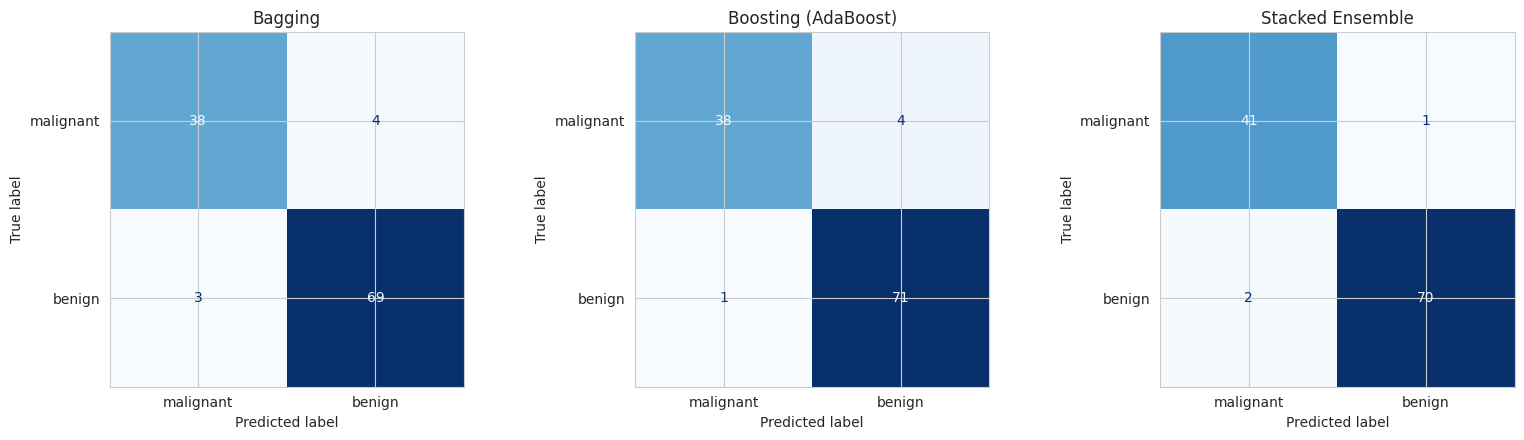

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

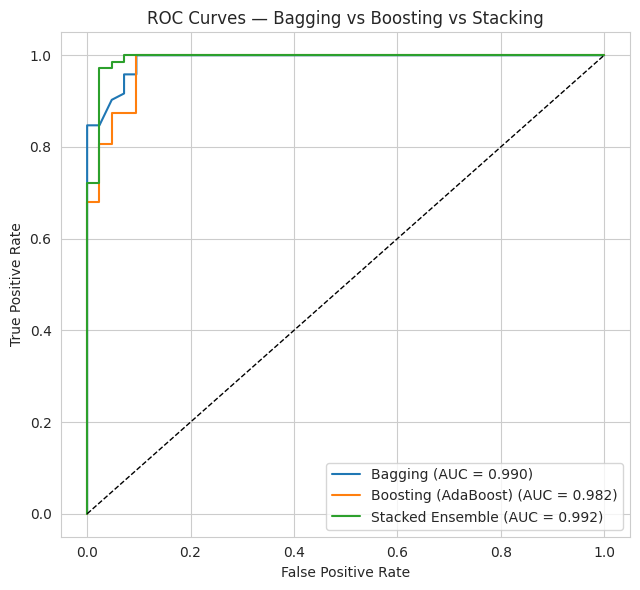

In [17]:
plt.figure(figsize=(6.5, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Bagging vs Boosting vs Stacking")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

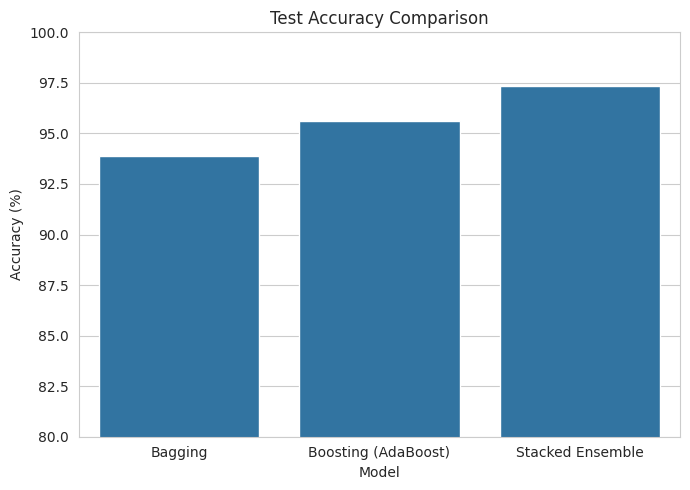

In [18]:
plt.figure(figsize=(7, 5))
sns.barplot(data=performance_df, x="Model", y="Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.ylim(80, 100)
plt.tight_layout()
plt.show()

## 8. Bias–Variance Behaviour: Learning Curves

Learning curves show training vs. cross-validation score as training-set size grows, which helps
visualise how Bagging (variance reduction) and Boosting (bias reduction) behave differently.

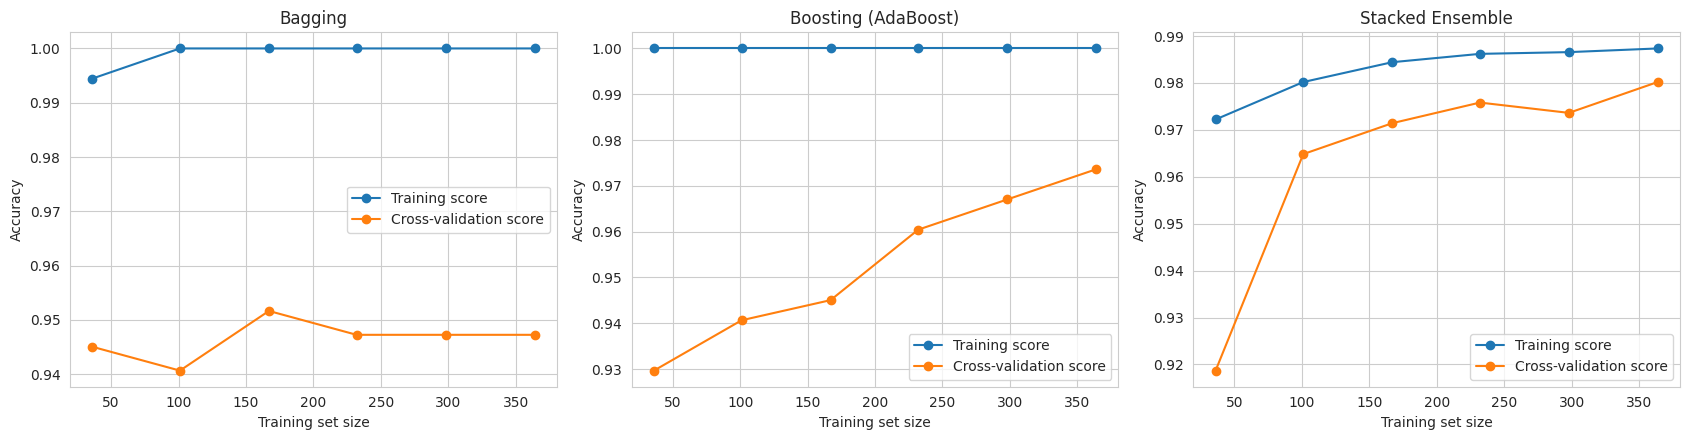

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train, cv=5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
    ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-validation score")
    ax.set_title(name)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")
    ax.legend()
plt.tight_layout()
plt.show()

## 9. Classification Reports

In [20]:
for name, model in models.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, model.predict(X_test_scaled), target_names=target_names))


=== Bagging ===
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114


=== Boosting (AdaBoost) ===
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


=== Stacked Ensemble ===
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
we

## 10. Observations & Conclusion

- **Bagging** reduces variance by training multiple Decision Trees independently on bootstrap
  samples and averaging their predictions, which stabilises high-variance base learners.
- **Boosting** (AdaBoost / Gradient Boosting) reduces bias by sequentially training models that
  focus on previously misclassified samples, improving performance on harder cases.
- **Stacking** combines heterogeneous base learners (SVM, Naive Bayes, Decision Tree) whose
  different inductive biases are exploited by a Logistic Regression meta-learner to make a final,
  often more accurate, prediction.
- Refer to `performance_df` above for the final quantitative comparison across all three ensembles
  on the held-out test set (569-sample WDBC dataset, 80–20 split).
